In [ ]:
# load the finished SROIE modeling table for lightweight classification experiments
import sys
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

model_df_path = PROJECT_ROOT / "outputs" / "sroie_model_df.csv"
sroie_model_df = pd.read_csv(model_df_path)

print(model_df_path)
print(sroie_model_df.shape)
display(sroie_model_df.head())

/Users/quentin/Documents/Computer/School/CMU/Spring_2026/38616/Gated-Risk-MCP/outputs/sroie_model_df.csv
(712, 46)


,doc_id,dataset,split,img_width,img_height,n_tokens,n_boxes,ocr_char_count,ocr_word_count,company_present,...,ocr_is_empty,aspect_ratio,company_hard,date_hard,address_hard,total_hard,low_ocr_support,proxy_risk_score,proxy_verify,proxy_high_risk
0,X00016469612,SROIE,train,463.0,1013.0,44,44,441,84,True,...,False,0.457058,True,False,False,False,False,1,False,False
1,X00016469619,SROIE,train,439.0,1004.0,48,48,637,102,True,...,False,0.437251,False,False,False,False,False,0,False,False
2,X00016469620,SROIE,train,459.0,949.0,54,54,668,121,True,...,False,0.483667,True,False,False,True,False,2,True,False
3,X00016469622,SROIE,train,461.0,933.0,60,60,525,105,True,...,False,0.494105,False,False,False,False,False,0,False,False
4,X00016469623,SROIE,train,463.0,1026.0,61,61,735,142,True,...,False,0.451267,False,False,False,True,False,1,False,False


In [41]:
# define the target and a compact first-pass feature set for lightweight models
TARGET_COL = "proxy_verify"

FEATURE_COLS = [
    "n_tokens",
    "n_boxes",
    "ocr_char_count",
    "ocr_word_count",
    "company_len",
    "date_len",
    "address_len",
    "total_len",
    "n_amount_like_tokens",
    "n_date_like_tokens",
    "token_box_ratio",
    "amount_token_ratio",
    "date_token_ratio",
    "avg_token_len",
    "avg_words_per_token",
    "anchors_present_count",
    "fields_present_count",
    "aspect_ratio",
    "has_total_anchor",
    "has_date_anchor",
    "has_cash_anchor",
]

X = sroie_model_df[FEATURE_COLS].copy()
y = sroie_model_df[TARGET_COL].astype(int).copy()

print(X.shape)
print(y.mean())
display(X.head())

(712, 21)
0.07443820224719101


,n_tokens,n_boxes,ocr_char_count,ocr_word_count,company_len,date_len,address_len,total_len,n_amount_like_tokens,n_date_like_tokens,...,amount_token_ratio,date_token_ratio,avg_token_len,avg_words_per_token,anchors_present_count,fields_present_count,aspect_ratio,has_total_anchor,has_date_anchor,has_cash_anchor
0,44,44,441,84,31,10,70,4,7,0,...,0.159091,0.000000,10.022727,1.909091,3,4,0.457058,True,True,True
1,48,48,637,102,22,10,63,5,11,0,...,0.229167,0.000000,13.270833,2.125000,2,4,0.437251,True,False,True
2,54,54,668,121,25,8,118,5,12,0,...,0.222222,0.000000,12.370370,2.240741,2,4,0.483667,True,False,True
3,60,60,525,105,19,10,44,5,16,1,...,0.266667,0.016667,8.750000,1.750000,3,4,0.494105,True,True,True
4,61,61,735,142,21,8,116,5,15,0,...,0.245902,0.000000,12.049180,2.327869,2,4,0.451267,True,False,True


In [42]:
# split the data once so all lightweight models are compared on the same train/test partition
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=60,
    stratify=y,
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(569, 21) (143, 21)
0.07381370826010544 0.07692307692307693


In [43]:
# define a shared evaluation helper for all lightweight models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate_binary_model(model_name, model, X_train, X_test, y_train, y_test, threshold=0.5):
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    y_pred = (y_score >= threshold).astype(int)

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pred_verify_rate": y_pred.mean(),
    }

In [44]:
# train four lightweight baselines: logistic regression, shallow tree, random forest, and gradient boosting
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

results = []

log_reg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=60)
tree = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=60)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=60,
)
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=60,
)

results.append(evaluate_binary_model("logistic_regression", log_reg, X_train, X_test, y_train, y_test))
results.append(evaluate_binary_model("decision_tree_depth4", tree, X_train, X_test, y_train, y_test))
results.append(evaluate_binary_model("random_forest_depth6", rf, X_train, X_test, y_train, y_test))
results.append(evaluate_binary_model("gradient_boosting", gb, X_train, X_test, y_train, y_test))

model_results_df = pd.DataFrame(results).sort_values(
    ["f1", "roc_auc", "precision", "recall", "accuracy"],
    ascending=False,
).reset_index(drop=True)

best_model_name = model_results_df.loc[0, "model"]
print(best_model_name)

display(model_results_df)

random_forest_depth6


,model,accuracy,precision,recall,f1,roc_auc,pred_verify_rate
0,random_forest_depth6,0.993007,0.916667,1.0,0.956522,1.000000,0.083916
1,gradient_boosting,0.993007,0.916667,1.0,0.956522,1.000000,0.083916
2,decision_tree_depth4,0.937063,0.550000,1.0,0.709677,0.993113,0.139860
3,logistic_regression,0.930070,0.523810,1.0,0.687500,0.995179,0.146853


In [45]:
# map model names to fitted model objects so later cells can inspect the selected best model
model_map = {
    "logistic_regression": log_reg,
    "decision_tree_depth4": tree,
    "random_forest_depth6": rf,
    "gradient_boosting": gb,
}

best_model = model_map[best_model_name]

In [46]:
# inspect feature importance for the selected best tree-based model when available
best_model.fit(X_train, y_train)

if hasattr(best_model, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "feature": FEATURE_COLS,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(feature_importance_df.head(15))
else:
    print(f"{best_model_name} does not expose feature_importances_")

,feature,importance
4,company_len,0.167598
6,address_len,0.155053
5,date_len,0.142250
7,total_len,0.138359
16,fields_present_count,0.132229
17,aspect_ratio,0.036531
1,n_boxes,0.035196
11,amount_token_ratio,0.029834
2,ocr_char_count,0.028790
3,ocr_word_count,0.026929


In [47]:
# inspect a few predicted high-risk receipts from the selected best model
if hasattr(best_model, "predict_proba"):
    best_scores = best_model.predict_proba(X_test)[:, 1]
else:
    best_scores = best_model.decision_function(X_test)

best_pred_df = X_test.copy()
best_pred_df["doc_id"] = sroie_model_df.loc[X_test.index, "doc_id"]
best_pred_df["y_true"] = y_test
best_pred_df["model_score"] = best_scores
best_pred_df["model_pred"] = (best_scores >= 0.5).astype(int)

display(
    best_pred_df
    .sort_values("model_score", ascending=False)
    .head(15)
)

,n_tokens,n_boxes,ocr_char_count,ocr_word_count,company_len,date_len,address_len,total_len,n_amount_like_tokens,n_date_like_tokens,...,anchors_present_count,fields_present_count,aspect_ratio,has_total_anchor,has_date_anchor,has_cash_anchor,doc_id,y_true,model_score,model_pred
163,64,64,573,113,0,0,0,0,20,0,...,3,0,0.475659,True,True,True,X51005677335(1),1,0.997932,1
169,0,0,0,0,0,0,0,0,0,0,...,0,0,0.438346,False,False,False,X51005685355(2),1,0.995341,1
119,0,0,0,0,0,0,0,0,0,0,...,0,0,0.392055,False,False,False,X51005605333(1),1,0.995341,1
172,0,0,0,0,0,0,0,0,0,0,...,0,0,0.405863,False,False,False,X51005685357(2),1,0.995341,1
113,40,40,563,102,0,0,0,0,9,0,...,2,0,0.470628,True,False,True,X51005605285(3),1,0.994589,1
306,46,46,700,126,0,0,0,0,7,0,...,3,0,0.408602,True,True,True,X51006334741(1),1,0.994434,1
318,38,38,513,90,0,0,0,0,9,0,...,3,0,0.505739,True,True,True,X51006335547(1),1,0.988505,1
156,70,70,614,126,0,0,0,0,23,0,...,3,0,0.448823,True,True,True,X51005677331(1),1,0.977376,1
293,31,31,424,67,0,0,0,0,8,0,...,3,0,0.510288,True,True,True,X51006329395(2),1,0.963552,1
526,51,51,579,107,0,0,0,0,9,1,...,2,0,0.516667,True,False,True,X51007103692(1),1,0.952425,1


In [48]:
# inspect a few predicted high-risk receipts from the random forest
rf_scores = rf.predict_proba(X_test)[:, 1]

rf_pred_df = X_test.copy()
rf_pred_df["doc_id"] = sroie_model_df.loc[X_test.index, "doc_id"]
rf_pred_df["y_true"] = y_test
rf_pred_df["rf_score"] = rf_scores
rf_pred_df["rf_pred"] = (rf_scores >= 0.5).astype(int)

display(
    rf_pred_df[
        ["doc_id", "y_true", "rf_score", "rf_pred", "n_tokens", "n_amount_like_tokens"]
    ]
    .sort_values("rf_score", ascending=False)
    .head(15)
)

,doc_id,y_true,rf_score,rf_pred,n_tokens,n_amount_like_tokens
163,X51005677335(1),1,0.997932,1,64,20
169,X51005685355(2),1,0.995341,1,0,0
119,X51005605333(1),1,0.995341,1,0,0
172,X51005685357(2),1,0.995341,1,0,0
113,X51005605285(3),1,0.994589,1,40,9
306,X51006334741(1),1,0.994434,1,46,7
318,X51006335547(1),1,0.988505,1,38,9
156,X51005677331(1),1,0.977376,1,70,23
293,X51006329395(2),1,0.963552,1,31,8
526,X51007103692(1),1,0.952425,1,51,9


In [49]:
# define a threshold grid and evaluate rf/gb across thresholds
import numpy as np

threshold_grid = np.round(np.arange(0.05, 0.96, 0.05), 2)
print(threshold_grid)

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


In [50]:
# fit rf and gb once, then collect metrics across thresholds
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

rf_scores = rf.predict_proba(X_test)[:, 1]
gb_scores = gb.predict_proba(X_test)[:, 1]

rows = []

for model_name, scores in [
    ("random_forest_depth6", rf_scores),
    ("gradient_boosting", gb_scores),
]:
    for threshold in threshold_grid:
        y_pred = (scores >= threshold).astype(int)

        rows.append({
            "model": model_name,
            "threshold": threshold,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "pred_verify_rate": y_pred.mean(),
            "tp": int(((y_test == 1) & (y_pred == 1)).sum()),
            "fp": int(((y_test == 0) & (y_pred == 1)).sum()),
            "tn": int(((y_test == 0) & (y_pred == 0)).sum()),
            "fn": int(((y_test == 1) & (y_pred == 0)).sum()),
        })

threshold_results_df = pd.DataFrame(rows)
display(threshold_results_df.head(10))

,model,threshold,accuracy,precision,recall,f1,pred_verify_rate,tp,fp,tn,fn
0,random_forest_depth6,0.05,0.706294,0.207547,1.0,0.343750,0.370629,11,42,90,0
1,random_forest_depth6,0.10,0.825175,0.305556,1.0,0.468085,0.251748,11,25,107,0
2,random_forest_depth6,0.15,0.902098,0.440000,1.0,0.611111,0.174825,11,14,118,0
3,random_forest_depth6,0.20,0.937063,0.550000,1.0,0.709677,0.139860,11,9,123,0
4,random_forest_depth6,0.25,0.965035,0.687500,1.0,0.814815,0.111888,11,5,127,0
5,random_forest_depth6,0.30,0.972028,0.733333,1.0,0.846154,0.104895,11,4,128,0
6,random_forest_depth6,0.35,0.972028,0.733333,1.0,0.846154,0.104895,11,4,128,0
7,random_forest_depth6,0.40,0.986014,0.846154,1.0,0.916667,0.090909,11,2,130,0
8,random_forest_depth6,0.45,0.986014,0.846154,1.0,0.916667,0.090909,11,2,130,0
9,random_forest_depth6,0.50,0.993007,0.916667,1.0,0.956522,0.083916,11,1,131,0


In [51]:
# sort the threshold grid results by f1, then recall, then precision
threshold_ranked_df = threshold_results_df.sort_values(
    ["f1", "recall", "precision", "accuracy"],
    ascending=False,
).reset_index(drop=True)

display(threshold_ranked_df)

,model,threshold,accuracy,precision,recall,f1,pred_verify_rate,tp,fp,tn,fn
0,random_forest_depth6,0.55,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
1,random_forest_depth6,0.60,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
2,random_forest_depth6,0.65,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
3,gradient_boosting,0.65,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
4,gradient_boosting,0.70,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
5,gradient_boosting,0.75,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
6,gradient_boosting,0.80,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
7,gradient_boosting,0.85,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
8,random_forest_depth6,0.50,0.993007,0.916667,1.000000,0.956522,0.083916,11,1,131,0
9,gradient_boosting,0.50,0.993007,0.916667,1.000000,0.956522,0.083916,11,1,131,0


In [52]:
# show the best few thresholds for each model side by side
top_per_model_df = (
    threshold_results_df
    .sort_values(["model", "f1", "recall", "precision", "accuracy"], ascending=[True, False, False, False, False])
    .groupby("model", as_index=False)
    .head(8)
    .reset_index(drop=True)
)

display(top_per_model_df)

,model,threshold,accuracy,precision,recall,f1,pred_verify_rate,tp,fp,tn,fn
0,gradient_boosting,0.65,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
1,gradient_boosting,0.70,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
2,gradient_boosting,0.75,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
3,gradient_boosting,0.80,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
4,gradient_boosting,0.85,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
5,gradient_boosting,0.50,0.993007,0.916667,1.000000,0.956522,0.083916,11,1,131,0
6,gradient_boosting,0.55,0.993007,0.916667,1.000000,0.956522,0.083916,11,1,131,0
7,gradient_boosting,0.60,0.993007,0.916667,1.000000,0.956522,0.083916,11,1,131,0
8,random_forest_depth6,0.55,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0
9,random_forest_depth6,0.60,1.000000,1.000000,1.000000,1.000000,0.076923,11,0,132,0


In [53]:
# pivot the main metrics so threshold tradeoffs are easier to scan
f1_pivot = threshold_results_df.pivot(index="threshold", columns="model", values="f1")
recall_pivot = threshold_results_df.pivot(index="threshold", columns="model", values="recall")
precision_pivot = threshold_results_df.pivot(index="threshold", columns="model", values="precision")
verify_rate_pivot = threshold_results_df.pivot(index="threshold", columns="model", values="pred_verify_rate")

print("F1")
display(f1_pivot)

print("Recall")
display(recall_pivot)

print("Precision")
display(precision_pivot)

print("Predicted verify rate")
display(verify_rate_pivot)

F1


model,gradient_boosting,random_forest_depth6
threshold,,
0.05,0.814815,0.343750
0.10,0.880000,0.468085
0.15,0.916667,0.611111
0.20,0.916667,0.709677
0.25,0.916667,0.814815
0.30,0.916667,0.846154
0.35,0.916667,0.846154
0.40,0.916667,0.916667
0.45,0.916667,0.916667


Recall


model,gradient_boosting,random_forest_depth6
threshold,,
0.05,1.000000,1.000000
0.10,1.000000,1.000000
0.15,1.000000,1.000000
0.20,1.000000,1.000000
0.25,1.000000,1.000000
0.30,1.000000,1.000000
0.35,1.000000,1.000000
0.40,1.000000,1.000000
0.45,1.000000,1.000000


Precision


model,gradient_boosting,random_forest_depth6
threshold,,
0.05,0.687500,0.207547
0.10,0.785714,0.305556
0.15,0.846154,0.440000
0.20,0.846154,0.550000
0.25,0.846154,0.687500
0.30,0.846154,0.733333
0.35,0.846154,0.733333
0.40,0.846154,0.846154
0.45,0.846154,0.846154


Predicted verify rate


model,gradient_boosting,random_forest_depth6
threshold,,
0.05,0.111888,0.370629
0.10,0.097902,0.251748
0.15,0.090909,0.174825
0.20,0.090909,0.139860
0.25,0.090909,0.111888
0.30,0.090909,0.104895
0.35,0.090909,0.104895
0.40,0.090909,0.090909
0.45,0.090909,0.090909


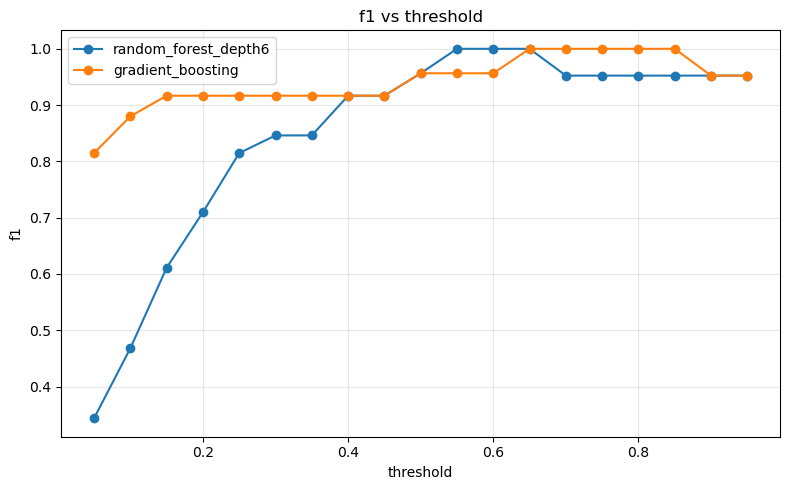

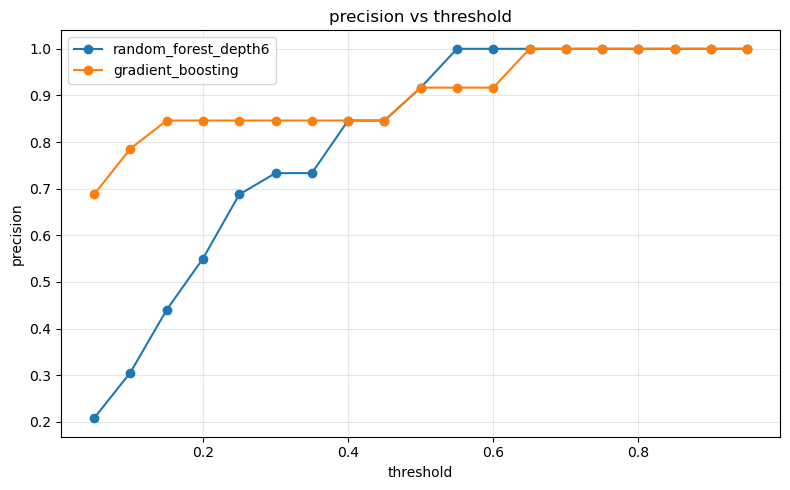

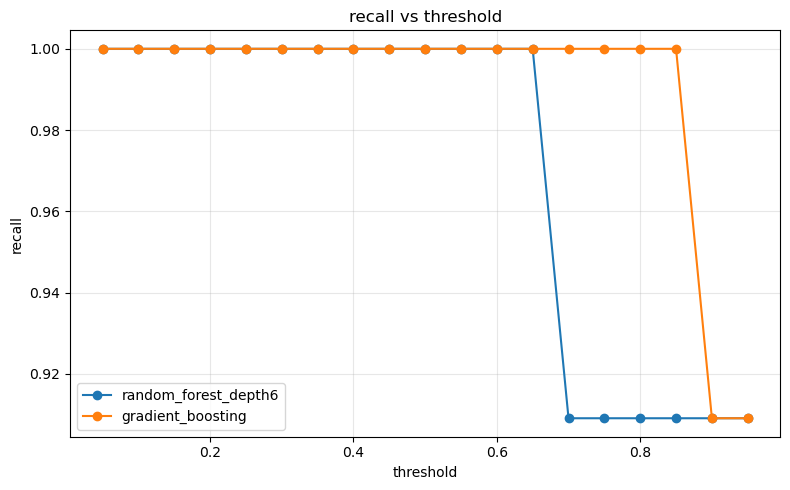

In [54]:
# plot threshold vs f1, precision, recall for rf and gb
import matplotlib.pyplot as plt

for metric in ["f1", "precision", "recall"]:
    plt.figure(figsize=(8, 5))
    for model_name in ["random_forest_depth6", "gradient_boosting"]:
        sub = threshold_results_df[threshold_results_df["model"] == model_name]
        plt.plot(sub["threshold"], sub[metric], marker="o", label=model_name)

    plt.xlabel("threshold")
    plt.ylabel(metric)
    plt.title(f"{metric} vs threshold")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

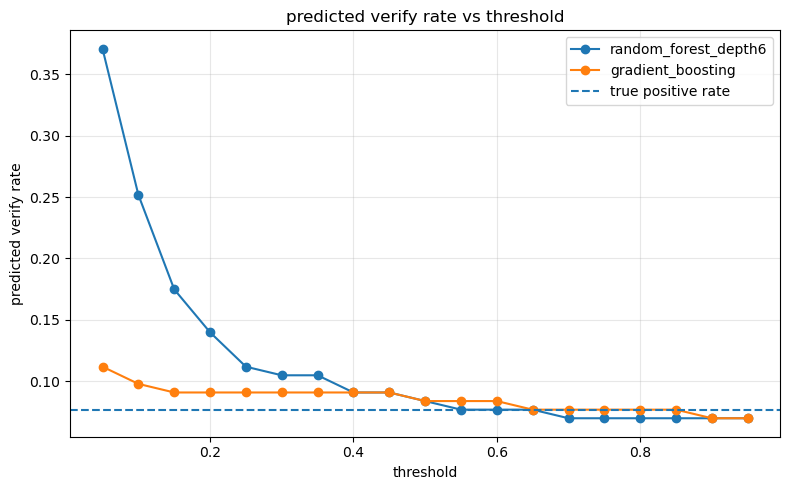

In [55]:
# plot threshold vs predicted verify rate for rf and gb
plt.figure(figsize=(8, 5))
for model_name in ["random_forest_depth6", "gradient_boosting"]:
    sub = threshold_results_df[threshold_results_df["model"] == model_name]
    plt.plot(sub["threshold"], sub["pred_verify_rate"], marker="o", label=model_name)

plt.axhline(y_test.mean(), linestyle="--", label="true positive rate")
plt.xlabel("threshold")
plt.ylabel("predicted verify rate")
plt.title("predicted verify rate vs threshold")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

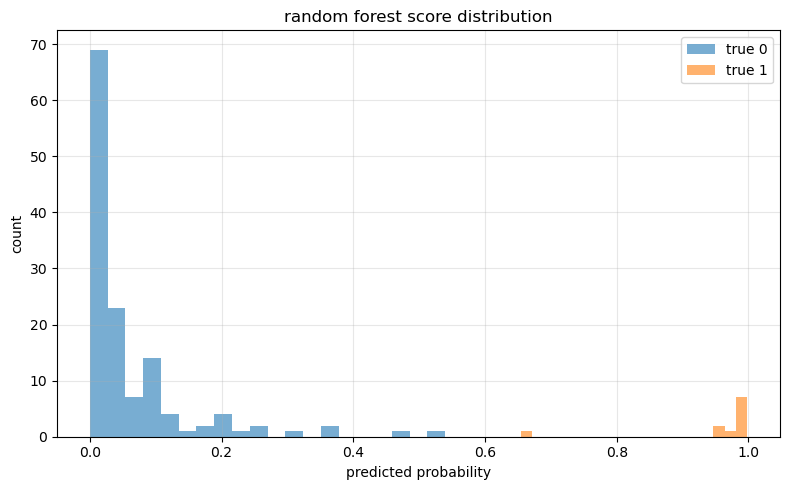

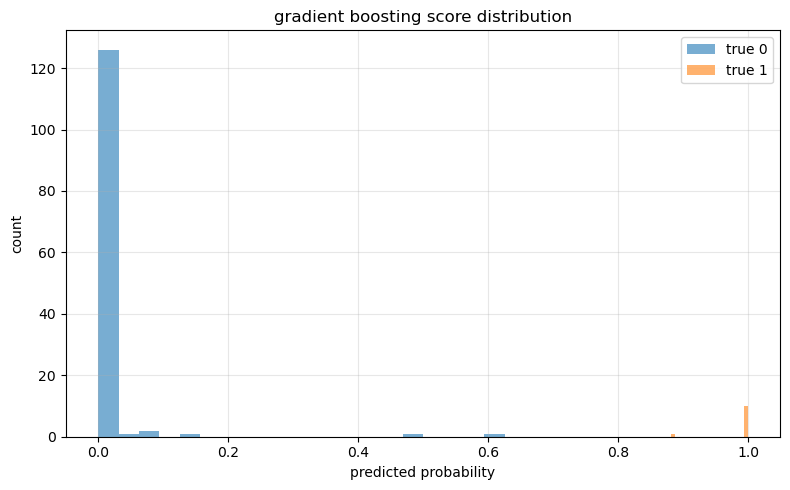

In [56]:
# plot probability distributions for rf and gb by true class
rf_scores = rf.predict_proba(X_test)[:, 1]
gb_scores = gb.predict_proba(X_test)[:, 1]

score_plot_df = pd.DataFrame({
    "y_true": y_test.values,
    "rf_score": rf_scores,
    "gb_score": gb_scores,
})

for score_col, title in [
    ("rf_score", "random forest score distribution"),
    ("gb_score", "gradient boosting score distribution"),
]:
    plt.figure(figsize=(8, 5))
    plt.hist(score_plot_df.loc[score_plot_df["y_true"] == 0, score_col], bins=20, alpha=0.6, label="true 0")
    plt.hist(score_plot_df.loc[score_plot_df["y_true"] == 1, score_col], bins=20, alpha=0.6, label="true 1")
    plt.xlabel("predicted probability")
    plt.ylabel("count")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()